Run IMSTE on MNIST, Fashion-MNIST, and Kuzushiji-MNIST. For each dataset, the gallery first shows a grid of sample images with one column per class and a configurable number of rows. It standardizes a stratified sample and fits IMSTE directly to the flattened image features. A following cell fits UMAP to the same standardized samples and shows each dataset's runtime in the plot title. The summary reports the sample and feature counts.

Remote datasets download on first use and are cached. Set `MAX_SAMPLES` or `N_EPOCHS` lower for a faster run. Graph construction uses exact Euclidean distances; `N_MSTS` controls the number of edge-disjoint trees.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "notebooks" / "high_dim_mst_gallery.py").is_file()),
    None,
)
if repo_root is not None:
    sys.path.insert(0, str(repo_root / "notebooks"))
    sys.path.insert(0, str(repo_root))

In [ ]:
from high_dim_mst_gallery import run_high_dim_mst_gallery

# Dataset
MAX_SAMPLES = 20000
SAMPLE_PLOT_ROWS = 5

#----
# Embedding
NEGATIVE_RATIO = 5
LAMBDA_REP = .5

#----
# Graph construction
N_MSTS = 10

gallery = run_high_dim_mst_gallery(
    max_samples=MAX_SAMPLES,
    sample_plot_rows=SAMPLE_PLOT_ROWS,
    negative_ratio=NEGATIVE_RATIO,
    lambda_rep=LAMBDA_REP,
    n_msts=N_MSTS,
)
gallery["summary"]


## UMAP embeddings

Fit UMAP to the same standardized dataset samples used for IMSTE. Each plot title reports the UMAP fit runtime for that dataset.

/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


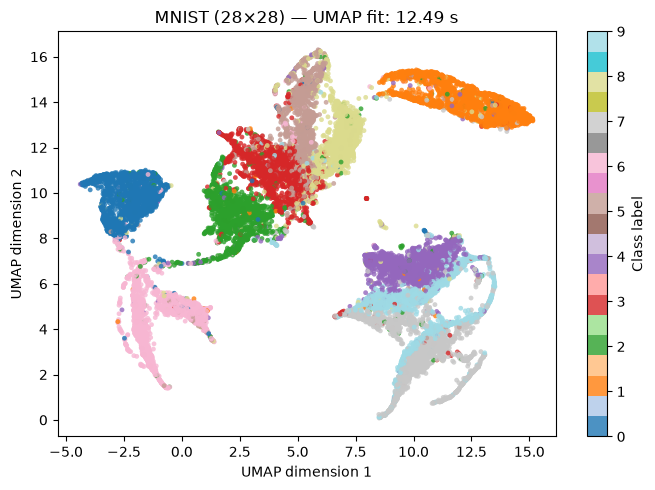

/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


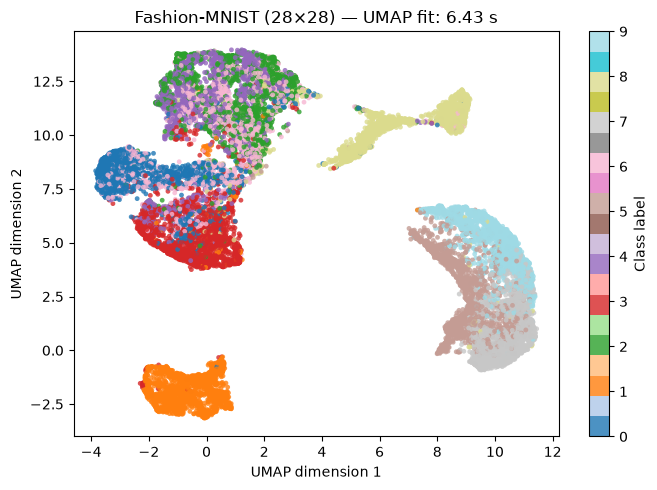

/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


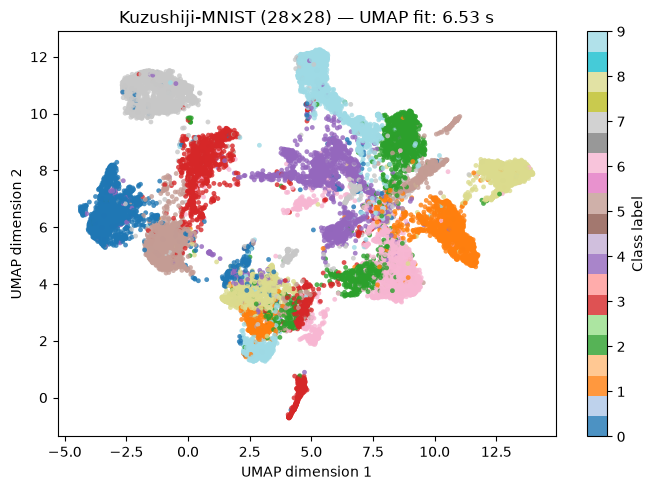

In [3]:
from time import perf_counter

import matplotlib.pyplot as plt
import umap
from IPython.display import display
from sklearn.preprocessing import StandardScaler

UMAP_RESULTS = {}
for dataset_name, (raw_X, labels) in gallery["datasets"].items():
    X_standardized = StandardScaler().fit_transform(raw_X)
    started = perf_counter()
    umap_embedding = umap.UMAP(
        n_components=2, n_neighbors=15, min_dist=0.1,
        metric="euclidean", random_state=42,
    ).fit_transform(X_standardized)
    elapsed = perf_counter() - started
    UMAP_RESULTS[dataset_name] = umap_embedding

    fig, ax = plt.subplots(figsize=(7, 5))
    points = ax.scatter(
        umap_embedding[:, 0], umap_embedding[:, 1],
        c=labels, cmap="tab20", s=12, alpha=0.8, linewidths=0,
    )
    ax.set_title(f"{dataset_name} — UMAP fit: {elapsed:.2f} s")
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    fig.colorbar(points, ax=ax, label="Class label")
    fig.tight_layout()
    display(fig)
    plt.close(fig)
